<a href="https://colab.research.google.com/github/dewangsahuji/Deep_Learning_Compu_vision/blob/Malaria_detection/MalariaX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np ## Maths
import matplotlib.pyplot as plt ## Plottings
import tensorflow_datasets as tfds ## Datasets
import tensorflow as tf ## Models

In [2]:
dataset , dataset_info = tfds.load('malaria',with_info=True , as_supervised=True , shuffle_files=True , split=['train'])

# Malaria Detection



## Data Preparation

In [3]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [4]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [5]:
for data in dataset[0].take(4):
    print(data)

(<tf.Tensor: shape=(103, 103, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=0>)
(<tf.Tensor: shape=(115, 157, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

In [6]:
TRAIN_RATIO = 0.8
TEST_RATIO = 0.1
VAL_RATIO = 0.1

# data_sets = tf.data.Dataset.range(10)



In [7]:
def splits(dataset , TRAIN_RATIO , VAL_RATIO , TEST_RATIO):
  train_dataset = dataset.take(int(len(dataset) * TRAIN_RATIO))

  val_dataset = dataset.skip(int(len(dataset) * TRAIN_RATIO)).take(int(len(dataset) * VAL_RATIO)) ## skip and Take

  test_dataset = dataset.skip(int(len(dataset) * (TRAIN_RATIO + VAL_RATIO))).take(int(len(dataset) * TEST_RATIO)) ## Skip and Take


  return train_dataset , val_dataset , test_dataset


In [8]:
train_dataset , val_dataset , test_dataset = splits(dataset[0] , TRAIN_RATIO , VAL_RATIO , TEST_RATIO)
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

22046
2755
2755


## Data Visualisation


In [9]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

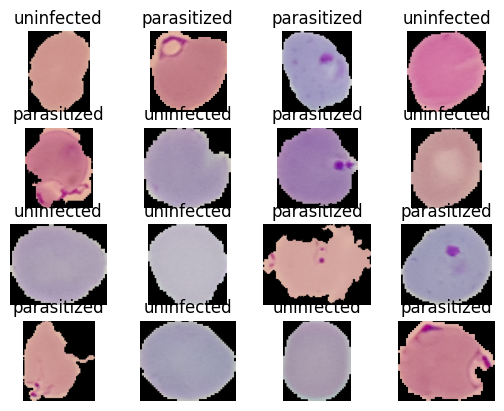

In [ ]:
for i, (image,label) in enumerate(train_dataset.take(16)) :
  ax = plt.subplot(4,4,i+1)
  plt.imshow(image)
  plt.title(dataset_info.features['label'].int2str(label))
  plt.axis("off")

## Data Preprocessing

In [10]:
IM_SIZE = 224

def resize_rescale(image, label):
    image = tf.image.resize(image, (IM_SIZE, IM_SIZE))
    image = tf.cast(image, tf.float32) / 255.0   # ensures float division
    return image, label

In [11]:
train_dataset = train_dataset.map(resize_rescale)
val_dataset = val_dataset.map(resize_rescale)
test_dataset = test_dataset.map(resize_rescale)


In [12]:
for image,data in train_dataset.take(1):
  print(image)

tf.Tensor(
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]], shape=(224, 224, 3), dtype=float32)


In [13]:
train_dataset = train_dataset.shuffle(buffer_size = 8 , reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(buffer_size = 8 , reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)
# test_dataset = test_dataset.shuffle(buffer_size = 8 , reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)

## Model Sub-Classing

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Layer


In [ ]:
class Feature_Extractor(Layer):
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super().__init__()

        # First block
        self.conv_1 = tf.keras.layers.Conv2D(
            filters=filters, kernel_size=kernel_size,
            strides=strides, padding=padding,
            activation=activation
        )
        self.batch_norm_1 = tf.keras.layers.BatchNormalization()
        self.max_pool_1 = tf.keras.layers.MaxPool2D(pool_size=pool_size, strides=2*strides)

        # Second block
        self.conv_2 = tf.keras.layers.Conv2D(
            filters=filters, kernel_size=kernel_size,
            strides=strides, padding=padding,
            activation=activation
        )
        self.batch_norm_2 = tf.keras.layers.BatchNormalization()
        self.max_pool_2 = tf.keras.layers.MaxPool2D(pool_size=pool_size, strides=2*strides)

    def call(self, x, training=False):
        # First block
        x = self.conv_1(x)
        x = self.batch_norm_1(x, training=training)
        x = self.max_pool_1(x)

        # Second block
        x = self.conv_2(x)
        x = self.batch_norm_2(x, training=training)
        x = self.max_pool_2(x)

        return x

feature_sub_classed = Feature_Extractor(16 , 3 , 1 , "valid" , "relu" , 2 )



In [ ]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3) , name='Input Image')

x = feature_sub_classed(func_input)
x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(100, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(10, activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)


output = tf.keras.layers.Dense(1, activation='sigmoid')(x)


feature_extractor_model = Model(inputs=func_input , outputs=output , name='Feature_Extractor')
feature_extractor_model.summary()

Model: "Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature__extractor_8            │ (None, 54, 54, 16)     │         2,896 │
│ (Feature_Extractor)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,670,057 (17.81 MB)

 Trainable params: 4,669,773 (17.81 MB)

 Non-trainable params: 284 (1.11 KB)

In [ ]:
class LenetModel(Model):
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(LenetModel,self).__init__()

        self.feature_extractor = Feature_Extractor(filters=filters,
                                                   kernel_size=kernel_size,
                                                   strides=strides,
                                                   padding=padding,
                                                   activation=activation,
                                                   pool_size=pool_size)

        self.flatten = Flatten()
        self.dense_1 = Dense(100, activation='relu')
        self.batch_norm_1 = BatchNormalization()

        self.dense_2 = Dense(10, activation='relu')
        self.batch_norm_2 = BatchNormalization()

        self.dense_3 = Dense(1, activation='sigmoid')

    def call(self, x, training=False):

        x = self.Feature_Extractor(x)
        x = self.flatten(x)

        x = self.dense_1(x)
        x = self.batch_norm_1(x)

        x = self.dense_2(x)
        x = self.batch_norm_2(x)

        x = self.dense_3(x)
        return x

lennet_sub_classed = LenetModel(16, 3, 1, "valid", "relu", 2)

lennet_sub_classed.summary()



Model: "lenet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature__extractor_9            │ ?                      │   0 (unbuilt) │
│ (Feature_Extractor)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Custom Layers


In [25]:
class NeuraLearnDense(Layer):
  def __init__(self, output_units , activation) :
    super(NeuraLearnDense , self).__init__()
    self.output_units = output_units
    self.activation = activation


  def build(self, input_shape):
    self.w = self.add_weight(shape=(input_shape[-1] , self.output_units),
                                    initializer="random_normal",
                                    trainable=True)
    self.b = self.add_weight(shape=(self.output_units,),
                                initializer="random_normal",
                                trainable=True
                                    )

  def call(self, inputs):
    if(self.activation == "relu"):
      return tf.nn.relu(tf.matmul(inputs , self.w) + self.b)

    elif(self.activation == "sigmoid"):
      return tf.math.sigmoid(tf.matmul(inputs , self.w) + self.b)

    else:
      return tf.matmul(inputs , self.w) + self.b

In [28]:
IM_SIZE = 224
lenet_custom_model = tf.keras.Sequential([
                             InputLayer(input_shape = (IM_SIZE, IM_SIZE, 3)),

                             tf.keras.layers.Conv2D(filters = 6, kernel_size = 3, strides=1, padding='valid', activation = 'relu'),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.MaxPool2D (pool_size = 2, strides= 2),

                             tf.keras.layers.Conv2D(filters = 16, kernel_size = 3, strides=1, padding='valid', activation = 'relu'),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.MaxPool2D (pool_size = 2, strides= 2),

                             tf.keras.layers.Flatten(),

                             NeuraLearnDense(100, activation = "relu"),
                             tf.keras.layers.BatchNormalization(),

                             NeuraLearnDense(10, activation = "relu"),
                             tf.keras.layers.BatchNormalization(),

                             NeuraLearnDense(1, activation = "sigmoid"),

])
lenet_custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neura_learn_dense               │ (None, 100)            │     4,665,700 │
│ (NeuraLearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neura_learn_dense_1             │ (None, 10)             │         1,010 │
│ (NeuraLearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neura_learn_dense_2             │ (None, 1)              │            11 │
│ (NeuraLearnDense)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

## Model Training

In [15]:
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten,InputLayer,BatchNormalization

In [ ]:
model = tf.keras.Sequential( [
    tf.keras.Input(shape=(IM_SIZE,IM_SIZE,3)),

    tf.keras.layers.Conv2D(filters=6, kernel_size=3 , strides=1 , padding='valid' , activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2 , strides=2),

    tf.keras.layers.Conv2D(filters=16, kernel_size=3 , strides=1 , padding='valid' , activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPool2D(pool_size=2 , strides=2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(100 , activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(10 , activation='relu'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(1 , activation='sigmoid'),

    ])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

### Model Compile


In [16]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam


In [26]:
metrics = [TruePositives(name='tp') , TrueNegatives(name='tn') , BinaryAccuracy(name='accuracy') ,
           FalsePositives(name='fp') , FalseNegatives(name='fn'),
           Precision(name='precision') , Recall(name='recall') ,
           RootMeanSquaredError(name='rmse'),AUC(name='auc')               ]


In [29]:
lenet_custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=metrics
)

In [30]:
history = lenet_custom_model.fit(train_dataset ,validation_data=val_dataset, epochs=5 , verbose=1)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 61s 77ms/step - accuracy: 0.8380 - auc: 0.9083 - fn: 714.1276 - fp: 767.8652 - loss: 0.3681 - precision: 0.8356 - recall: 0.8470 - rmse: 0.3360 - tn: 4750.9263 - tp: 4823.0288 - val_accuracy: 0.9372 - val_auc: 0.9683 - val_fn: 60.0000 - val_fp: 113.0000 - val_loss: 0.2058 - val_precision: 0.9215 - val_recall: 0.9567 - val_rmse: 0.2330 - val_tn: 1255.0000 - val_tp: 1327.0000
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.7379 - auc: 0.8142 - fn: 1737.1898 - fp: 1415.1000 - loss: 0.5050 - precision: 0.7518 - recall: 0.7110 - rmse: 0.4071 - tn: 4103.6665 - tp: 3799.9912 - val_accuracy: 0.7503 - val_auc: 0.9394 - val_fn: 19.0000 - val_fp: 669.0000 - val_loss: 0.8000 - val_precision: 0.6724 - val_recall: 0.9864 - val_rmse: 0.4584 - val_tn: 694.0000 - val_tp: 1373.0000
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 39s 57ms/step - accuracy: 0.9162 - auc: 0.9663 - fn: 378.3565 - fp: 535.5840 - loss: 0.2216 - precision: 0.9061 - recall: 0.9302

In [ ]:
# train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
# val_dataset

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

## Functional API


In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

In [ ]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3) , name='Input Image')

x = tf.keras.layers.Conv2D(filters=6, kernel_size=3 , strides=1 , padding='valid' , activation='relu')(func_input)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=2 , strides=2)(x)

x = tf.keras.layers.Conv2D(filters=16, kernel_size=3 , strides=1 , padding='valid' , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=2 , strides=2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(100 , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(10 , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

func_output = tf.keras.layers.Dense(1 , activation='sigmoid')(x)


# model.summary()

lenet_model = Model(inputs=func_input , outputs=func_output , name='Lenet_model')
lenet_model.summary()



Model: "Lenet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

#### Feature Extractor Model

In [ ]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3) , name='Input Image')

x = tf.keras.layers.Conv2D(filters=6, kernel_size=3 , strides=1 , padding='valid' , activation='relu')(func_input)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=2 , strides=2)(x)

x = tf.keras.layers.Conv2D(filters=16, kernel_size=3 , strides=1 , padding='valid' , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

output = tf.keras.layers.MaxPool2D(pool_size=2 , strides=2)(x)

feature_extractor_model = Model(inputs=func_input , outputs=output , name='Feature_Extractor')
feature_extractor_model.summary()

Model: "Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,136 (4.44 KB)

 Trainable params: 1,092 (4.27 KB)

 Non-trainable params: 44 (176.00 B)

In [ ]:
func_input = Input(shape=(IM_SIZE,IM_SIZE,3) , name='Input Image')

x = feature_extractor_model(func_input)
x = tf.keras.layers.Flatten()(x)

x = tf.keras.layers.Dense(100 , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(10 , activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)

func_output = tf.keras.layers.Dense(1 , activation='sigmoid')(x)


# model.summary()

lenet_model_func = Model(inputs=func_input , outputs=func_output , name='Lenet_model_func')
lenet_model_func.summary()








NameError: name 'IM_SIZE' is not defined

## Graphs


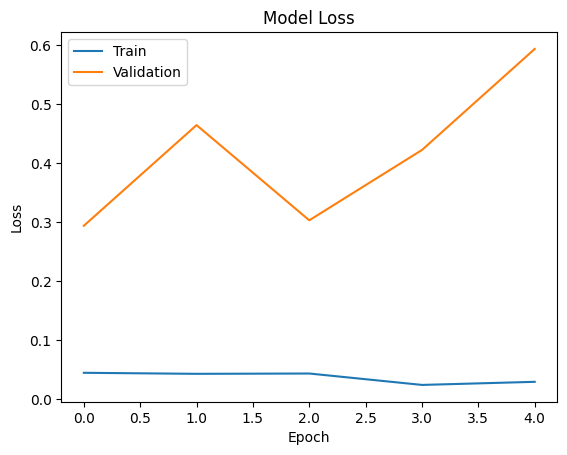

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

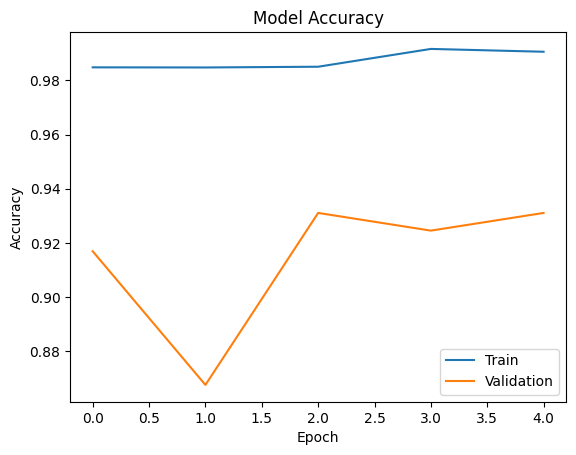

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()





## Model Evaluating and Testing

In [28]:
test_dataset = test_dataset.batch(1)

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
test_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [26]:
model.evaluate(test_dataset)

NameError: name 'model' is not defined

In [ ]:
def parasite_or_not (x):
  if(x<=0.5):
    return str("P")
  else:
    return str("U")




In [ ]:
parasite_or_not(model.predict(test_dataset.take(1))[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


'U'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


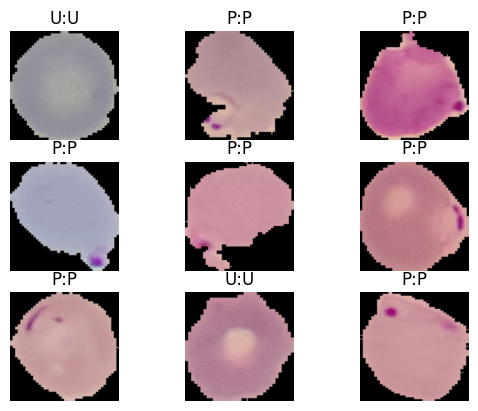

In [ ]:
for i, (image,label) in enumerate(test_dataset.take(9)):
  ax = plt.subplot(3,3,i+1)
  plt.imshow(image[0])
  plt.title( str(parasite_or_not(label.numpy()[0]))  + ":" + str(parasite_or_not(model.predict(image)[0][0])) )
  plt.axis("off")

### Precision Recall and Accuracy


In [18]:
import sklearn
from sklearn.metrics import confusion_matrix
import seaborn as sns



In [19]:
from tensorflow.keras.metrics import BinaryAccuracy , FalseNegatives ,TruePositives , TrueNegatives , FalsePositives , Precision , Recall ,AUC

In [33]:
lenet_custom_model.evaluate(test_dataset)

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

#### Visualising Confusion Matrix

In [20]:
labels =[]
inp = []

for x,y in test_dataset.map(resize_rescale).as_numpy_iterator():
  labels.append(y)
  inp.append(x)

In [22]:
print(inp)

[array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32), array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [

In [36]:
np.array(inp).shape

(2755, 224, 224, 3)

In [37]:
print(np.array(inp).shape)

(2755, 224, 224, 3)


In [38]:
labels = np.array( [ i[0] for i in labels])

IndexError: invalid index to scalar variable.

In [43]:
predicted = lenet_custom_model.predict(np.array(inp))
print(predicted[:,0])

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
[6.5844305e-31 6.6597590e-31 6.7799806e-31 ... 6.9912517e-31 6.2352983e-31
 6.5931776e-31]


In [48]:
threshold = 0.1

cm = confusion_matrix(labels, predicted[:,0] > threshold)
print(cm)


[[1391    0]
 [1364    0]]


# Saving Model and Loading

In [ ]:
# model.save("lenet")
model.save("lenet.hdf5")

In [ ]:
model = tf.keras.models.load_model("lenet.hdf5")


In [ ]:
model = tf.keras.models.load_model("lenet.hdf5")
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,299 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
model.save_weights("lenet_weights.weights.h5")


In [ ]:
lenet_weights_model = model.load_weights("weights/lenet_weights")
